# **Hospital Readmission Rates - ML Pipeline**

## Objectives

* Create Modelling Dataset
* Push data through ML pipeline for predictive analytics

## Inputs

* Dataset from the "Clean Data" file, imported from Kaggle

## Outputs

* Modelling Data, stored in "Modelling Data" file
* ML Model
    * Trained
    * Tested
    * Evaluated




---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\naqas\\OneDrive\\Documents\\Coding\\CI_Projects\\hospital_readmission_rates_analysis\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\naqas\\OneDrive\\Documents\\Coding\\CI_Projects\\hospital_readmission_rates_analysis'

---

# Import Packages

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from imblearn.over_sampling import SMOTE

---

# Import Clean Data 

In [5]:
clean_hospital_data_df = pd.read_csv("data_files/CleanData/clean_hospital_data.csv")
clean_hospital_data_df

,race,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),1,41,0,1,0,0,0,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),3,59,0,18,0,0,0,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),2,11,5,13,2,0,1,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),2,44,1,16,0,0,0,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),1,51,0,8,0,0,0,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99467,AfricanAmerican,Male,[70-80),3,51,0,16,0,0,0,...,No,Down,No,No,No,No,No,Ch,Yes,>30
99468,AfricanAmerican,Female,[80-90),5,33,3,18,0,0,1,...,No,Steady,No,No,No,No,No,No,Yes,NO
99469,Caucasian,Male,[70-80),1,53,0,9,1,0,0,...,No,Down,No,No,No,No,No,Ch,Yes,NO
99470,Caucasian,Female,[80-90),10,45,2,21,0,0,1,...,No,Up,No,No,No,No,No,Ch,Yes,NO


---

## _**Machine Learning Pipeline**_

### _Encoding_

All categories must be encoded before ML model training. The types of encoding used is as follows:

* Mapped encoding - mapping "1" and "0" to binary columns
* One-hot encoding - encoding of values with no natural order
* Ordinal encoding - encoding of values with natural order

As the target variable is "Readmitted", for the modelling we will be binarising it.

In [6]:
clean_hospital_data_df["readmitted"] = (clean_hospital_data_df["readmitted"] == "<30").astype(int)
clean_hospital_data_df["readmitted"].value_counts()

readmitted
0    88308
1    11164
Name: count, dtype: int64

We will also be binarising the two testing columns (Max Glucose Serum & A1Cresult)

In [7]:
clean_hospital_data_df["max_glu_serum"] = (clean_hospital_data_df["max_glu_serum"] != "No Test Performed").astype(int)
clean_hospital_data_df["max_glu_serum"].value_counts()

max_glu_serum
0    94183
1     5289
Name: count, dtype: int64

In [8]:
clean_hospital_data_df["A1Cresult"] = (clean_hospital_data_df["A1Cresult"] != "No Test Performed").astype(int)
clean_hospital_data_df["A1Cresult"].value_counts()

A1Cresult
0    82879
1    16593
Name: count, dtype: int64

Next, we will map encode all binarised categories.

In [9]:
clean_hospital_data_df["gender_encoded"] = clean_hospital_data_df["gender"].map({"Male":1, "Female":0})
clean_hospital_data_df["diabetesMed_encoded"] = clean_hospital_data_df["diabetesMed"].map({"Yes":1,"No":0})
clean_hospital_data_df["change_encoded"] = clean_hospital_data_df["change"].map({"Ch":1,"No":0})

clean_hospital_data_df

,race,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,gender_encoded,diabetesMed_encoded,change_encoded
0,Caucasian,Female,[0-10),1,41,0,1,0,0,0,...,No,No,No,No,No,No,0,0,0,0
1,Caucasian,Female,[10-20),3,59,0,18,0,0,0,...,No,No,No,No,Ch,Yes,0,0,1,1
2,AfricanAmerican,Female,[20-30),2,11,5,13,2,0,1,...,No,No,No,No,No,Yes,0,0,1,0
3,Caucasian,Male,[30-40),2,44,1,16,0,0,0,...,No,No,No,No,Ch,Yes,0,1,1,1
4,Caucasian,Male,[40-50),1,51,0,8,0,0,0,...,No,No,No,No,Ch,Yes,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99467,AfricanAmerican,Male,[70-80),3,51,0,16,0,0,0,...,No,No,No,No,Ch,Yes,0,1,1,1
99468,AfricanAmerican,Female,[80-90),5,33,3,18,0,0,1,...,No,No,No,No,No,Yes,0,0,1,0
99469,Caucasian,Male,[70-80),1,53,0,9,1,0,0,...,No,No,No,No,Ch,Yes,0,1,1,1
99470,Caucasian,Female,[80-90),10,45,2,21,0,0,1,...,No,No,No,No,Ch,Yes,0,0,1,1


Next, all columns requiring one-hot encoding will be encoded.

In [10]:
clean_hospital_data_df = pd.get_dummies(clean_hospital_data_df, columns=["race","diag_1", "diag_2","diag_3","metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride", 
             "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone", "rosiglitazone", 
             "acarbose", "miglitol", "troglitazone", "tolazamide", "examide", "citoglipton", "insulin", 
             "glyburide-metformin", "glipizide-metformin", "glimepiride-pioglitazone", "metformin-rosiglitazone", 
             "metformin-pioglitazone"], drop_first=True)
clean_hospital_data_df.columns.to_list()

['gender',
 'age',
 'time_in_hospital',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'max_glu_serum',
 'A1Cresult',
 'change',
 'diabetesMed',
 'readmitted',
 'gender_encoded',
 'diabetesMed_encoded',
 'change_encoded',
 'race_Asian',
 'race_Caucasian',
 'race_Hispanic',
 'race_Other',
 'diag_1_Diabetes',
 'diag_1_Digestive',
 'diag_1_Endocrine',
 'diag_1_Genitourinary',
 'diag_1_Injury',
 'diag_1_Musculoskeletal',
 'diag_1_Neoplasms',
 'diag_1_Other',
 'diag_1_Respiratory',
 'diag_2_Diabetes',
 'diag_2_Digestive',
 'diag_2_Endocrine',
 'diag_2_Genitourinary',
 'diag_2_Injury',
 'diag_2_Musculoskeletal',
 'diag_2_Neoplasms',
 'diag_2_No diagnosis',
 'diag_2_Other',
 'diag_2_Respiratory',
 'diag_3_Diabetes',
 'diag_3_Digestive',
 'diag_3_Endocrine',
 'diag_3_Genitourinary',
 'diag_3_Injury',
 'diag_3_Musculoskeletal',
 'diag_3_Neoplasms',
 'diag_3_No diagnosis',
 'diag_3_Other',
 'diag_3_Respiratory',
 'me

Finally, Ordinal encoding must be performed on the Age column as the values are set as ranges.

In [11]:
age_order = [['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)',
       '[60-70)', '[70-80)', '[80-90)', '[90-100)']]

oe = OrdinalEncoder(categories=age_order)
clean_hospital_data_df["age_encoded"] = oe.fit_transform(clean_hospital_data_df[["age"]])
clean_hospital_data_df.columns.to_list()

['gender',
 'age',
 'time_in_hospital',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'max_glu_serum',
 'A1Cresult',
 'change',
 'diabetesMed',
 'readmitted',
 'gender_encoded',
 'diabetesMed_encoded',
 'change_encoded',
 'race_Asian',
 'race_Caucasian',
 'race_Hispanic',
 'race_Other',
 'diag_1_Diabetes',
 'diag_1_Digestive',
 'diag_1_Endocrine',
 'diag_1_Genitourinary',
 'diag_1_Injury',
 'diag_1_Musculoskeletal',
 'diag_1_Neoplasms',
 'diag_1_Other',
 'diag_1_Respiratory',
 'diag_2_Diabetes',
 'diag_2_Digestive',
 'diag_2_Endocrine',
 'diag_2_Genitourinary',
 'diag_2_Injury',
 'diag_2_Musculoskeletal',
 'diag_2_Neoplasms',
 'diag_2_No diagnosis',
 'diag_2_Other',
 'diag_2_Respiratory',
 'diag_3_Diabetes',
 'diag_3_Digestive',
 'diag_3_Endocrine',
 'diag_3_Genitourinary',
 'diag_3_Injury',
 'diag_3_Musculoskeletal',
 'diag_3_Neoplasms',
 'diag_3_No diagnosis',
 'diag_3_Other',
 'diag_3_Respiratory',
 'me

In [12]:
clean_hospital_data_df.drop(columns=["gender", "age", "change", "diabetesMed"], inplace=True)
clean_hospital_data_df.columns.to_list()

['time_in_hospital',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'max_glu_serum',
 'A1Cresult',
 'readmitted',
 'gender_encoded',
 'diabetesMed_encoded',
 'change_encoded',
 'race_Asian',
 'race_Caucasian',
 'race_Hispanic',
 'race_Other',
 'diag_1_Diabetes',
 'diag_1_Digestive',
 'diag_1_Endocrine',
 'diag_1_Genitourinary',
 'diag_1_Injury',
 'diag_1_Musculoskeletal',
 'diag_1_Neoplasms',
 'diag_1_Other',
 'diag_1_Respiratory',
 'diag_2_Diabetes',
 'diag_2_Digestive',
 'diag_2_Endocrine',
 'diag_2_Genitourinary',
 'diag_2_Injury',
 'diag_2_Musculoskeletal',
 'diag_2_Neoplasms',
 'diag_2_No diagnosis',
 'diag_2_Other',
 'diag_2_Respiratory',
 'diag_3_Diabetes',
 'diag_3_Digestive',
 'diag_3_Endocrine',
 'diag_3_Genitourinary',
 'diag_3_Injury',
 'diag_3_Musculoskeletal',
 'diag_3_Neoplasms',
 'diag_3_No diagnosis',
 'diag_3_Other',
 'diag_3_Respiratory',
 'metformin_No',
 'metformin_Steady',
 'metformin_

---

### _Create new Dataframe from new dataset_

In [13]:
clean_hospital_data_df.to_csv("data_files/ModellingData/modelling_hospital_data.csv", index = False)

In [14]:
hospital_modelling_df = pd.read_csv("data_files/ModellingData/modelling_hospital_data.csv")
hospital_modelling_df

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,max_glu_serum,A1Cresult,readmitted,...,insulin_No,insulin_Steady,insulin_Up,glyburide-metformin_No,glyburide-metformin_Steady,glyburide-metformin_Up,glipizide-metformin_Steady,glimepiride-pioglitazone_Steady,metformin-pioglitazone_Steady,age_encoded
0,1,41,0,1,0,0,0,0,0,0,...,True,False,False,True,False,False,False,False,False,0.0
1,3,59,0,18,0,0,0,0,0,0,...,False,False,True,True,False,False,False,False,False,1.0
2,2,11,5,13,2,0,1,0,0,0,...,True,False,False,True,False,False,False,False,False,2.0
3,2,44,1,16,0,0,0,0,0,0,...,False,False,True,True,False,False,False,False,False,3.0
4,1,51,0,8,0,0,0,0,0,0,...,False,True,False,True,False,False,False,False,False,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99467,3,51,0,16,0,0,0,0,1,0,...,False,False,False,True,False,False,False,False,False,7.0
99468,5,33,3,18,0,0,1,0,0,0,...,False,True,False,True,False,False,False,False,False,8.0
99469,1,53,0,9,1,0,0,0,0,0,...,False,False,False,True,False,False,False,False,False,7.0
99470,10,45,2,21,0,0,1,0,0,0,...,False,False,True,True,False,False,False,False,False,8.0


---

### _Define Features and Target Variables_

In [15]:
X = hospital_modelling_df.drop(["readmitted"], axis=1)
y = hospital_modelling_df["readmitted"]

The features and the targets for the models were defined.

---

### _Train-Test Split_

In [16]:
X_train,X_test, y_train, y_test = train_test_split(X,y, train_size=0.8, stratify=y, random_state=38)

The data was split into an 80:20 train test split. The "Stratify" function was used to maintain data proportionality in the train test split.

---

### _Scaling_

In [17]:
diabetes_scaler = StandardScaler()
X_train = diabetes_scaler.fit_transform(X_train)
X_test = diabetes_scaler.transform(X_test)

Scaling is done to balance the weights of different numerical values within the modelling dataset.

---

### _Class Imbalance_

In [18]:
# smote = SMOTE( random_state = 17)
# X_train, y_train = smote.fit_resample(X_train, y_train)

This is health data and it is very common to have class imbalances in health data. To deal with the imbalance, SMOTE is used to create synthetic data and balance the classes. This will not affect the train-test split as it has been done prior to fixing the class imbalance.

_**IMPORTANT NOTE**_

SMOTE was commented out as the "class_weight = "balanced" " function in the model training worked better to provide better predictive models.

---

### _Model Training_

In [19]:
lr_model = LogisticRegression( random_state= 44, max_iter= 1000, class_weight = "balanced")
rf_model = RandomForestClassifier(random_state=26, class_weight = "balanced")

lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=26)

Logistic regression and Random forest models were used. The Logistic Regression model initially reached it's max iterations before being able to find the optimal solution therefore, the max iterations were manually adjusted to "1000" to allow the model to work until the optimal solution was found.

As mentioned above, the " class_weight" function was used to balance the models better.

---

### _Model Evaluation_

It is necessary to evaluate the accurace of the models to help determine which model is best for predicion with this dataset.

In [20]:
for name, model in [("Logistic Regression", lr_model),("Random Forest", rf_model)]:
    y_prediction = model.predict(X_test)
    print(f"\n{name}")
    print(f"Accuracy:{accuracy_score(y_test,y_prediction):.2f}")
    print(classification_report(y_test, y_prediction))


Logistic Regression
Accuracy:0.66
              precision    recall  f1-score   support

           0       0.91      0.68      0.78     17662
           1       0.16      0.50      0.25      2233

    accuracy                           0.66     19895
   macro avg       0.54      0.59      0.51     19895
weighted avg       0.83      0.66      0.72     19895


Random Forest
Accuracy:0.89
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     17662
           1       0.45      0.00      0.01      2233

    accuracy                           0.89     19895
   macro avg       0.67      0.50      0.47     19895
weighted avg       0.84      0.89      0.84     19895



Each Model was assessed against a variety of criteria:

*  Precision - this measures how precise the model is in terms of predicting readmittance. It is compared to how many readmitted records were real.
* Recall - this measures how many of the actual readmitted cases documented were caught by the model
* F1-score - this calculates the balance of Precision and Recall. A high F1 score means that the model is really good with high precision and high recall.

This is what the results displayed for each model:

* Logistic Regression model:
    * This model showed an overall accuracy of 66%
    * The Precision at predicting readmission was 16%
    * The Recall at identifying real readmission records was 50%
    * The F1-score was about 25%
    * Overall, the model was good at recalling and identifying true readmission records but had very low precision.
* Random Forest model:
    * This model showed an overall accuracy of 89%
    * The Precision was 45%
    * The Recall was 0%
    * The F1-score was 1%
    * Overall, this model was much better at precisely at predicting and identifying "Readmitted = Yes" scenarios however, it had poor recall and f1 scores. The reason this model had an accuracy of 89% was that it was able to identify "Readmitted= No" scenarios. This means that the accuracy result of this model is not reliable, especially in this case as it is important for the evaluation scores to be higher for the "Readmitted = Yes" section.

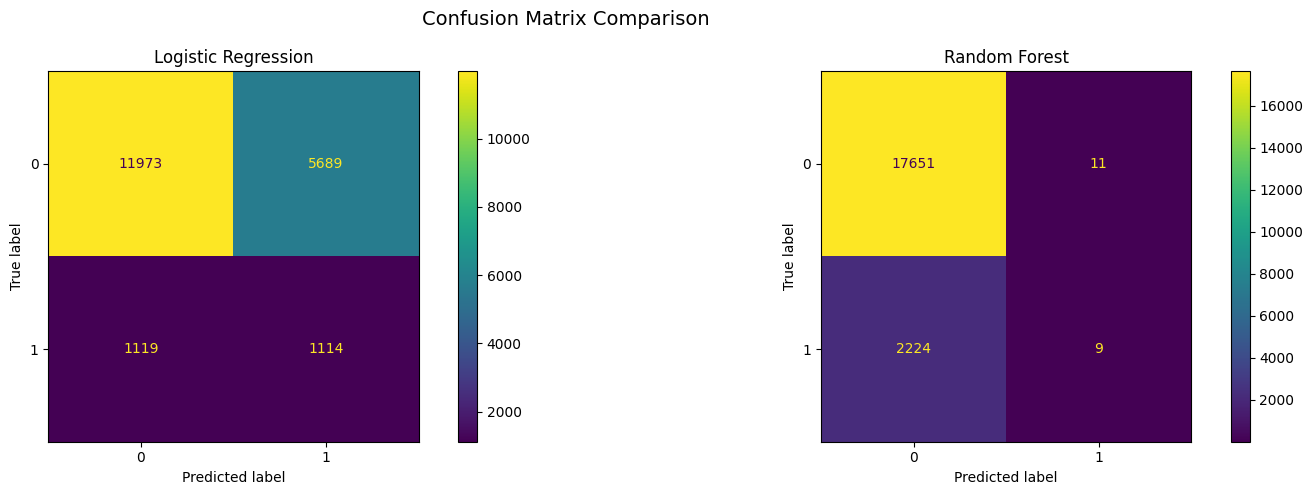

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (name, model) in zip(axes, [("Logistic Regression", lr_model), ("Random Forest", rf_model)]):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax)
    ax.set_title(f"{name}")

plt.suptitle("Confusion Matrix Comparison", fontsize=14)
plt.tight_layout()
plt.show()

From the above matrices:

* We can see that the Logistic Regression model showed the most True Positives and False Negatives. The True positives are essential as this shows that it was able to identify more "Readmitted = Yes" cases

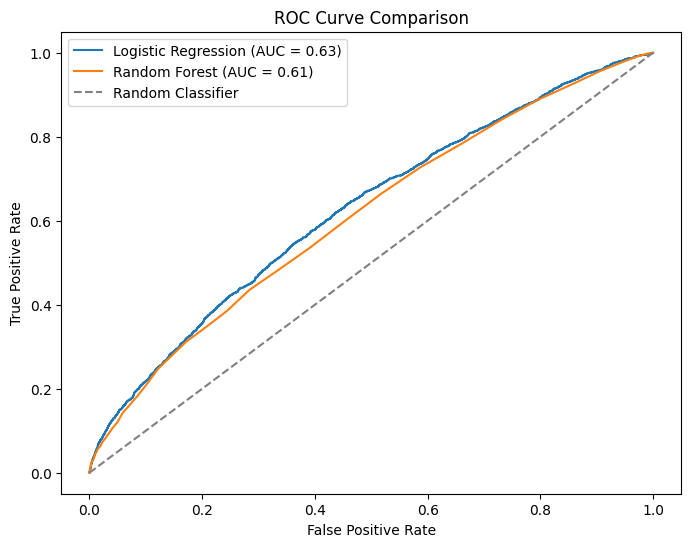

In [23]:
plt.figure(figsize=(8, 6))

for name, model in [("Logistic Regression", lr_model), ("Random Forest", rf_model)]:
    y_probability = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probability)
    auc = roc_auc_score(y_test, y_probability)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

We can see that the Logistic Regression model perfomed best out of the two models with a score of 0.63. Without looking at the scores we can also see by looking at the graph that the line for Logistic Regression is closest to the left side of the graph. This indicates that the model was better at predicting True Positives than the other model. The Random Forest model line is however, quite close to the Logistic regression line which indicates it also performed almost equally as well with a score of 0.61. Finally, a "Random Classifier" line is drawn. This represents a model that would place random guesses. This line indicates that any line above this would be a better model than random guessing.

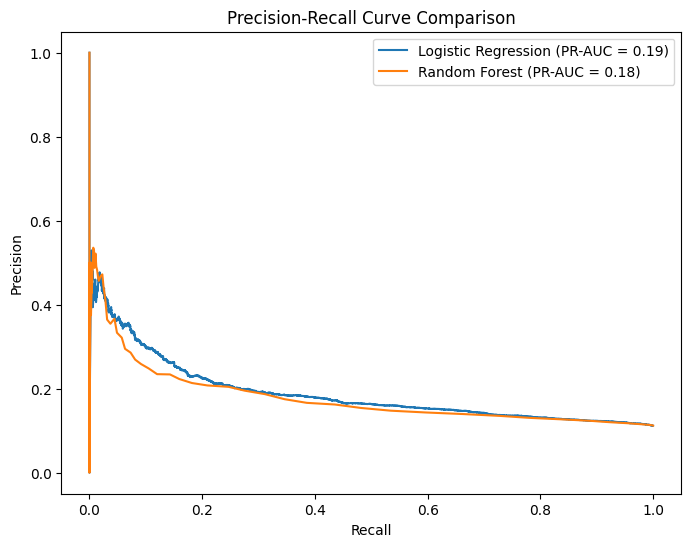

In [24]:
plt.figure(figsize=(8, 6))

for name, model in [("Logistic Regression", lr_model), ("Random Forest", rf_model)]:
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f"{name} (PR-AUC = {pr_auc:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

In [25]:
baseline = y_test.sum() / len(y_test)
print(f"Baseline PR-AUC: {baseline:.2f}")

Baseline PR-AUC: 0.11


We can see that the baseline for the dataset is: 0.11. The evaluation of each model is as follows:

Logistic Regression - The AUC score for this was 0.19. This means that this model was the best at detecting readmittance occurrences.
Random Forest - The AUC score for this was 0.18. This means that this was only slightly a poorer model at predicting readmittance occurrences.

Both models, are not too far from the baseline and so in the future, further modelling and data analysis would be required

Text(0, 0.5, 'Feature')

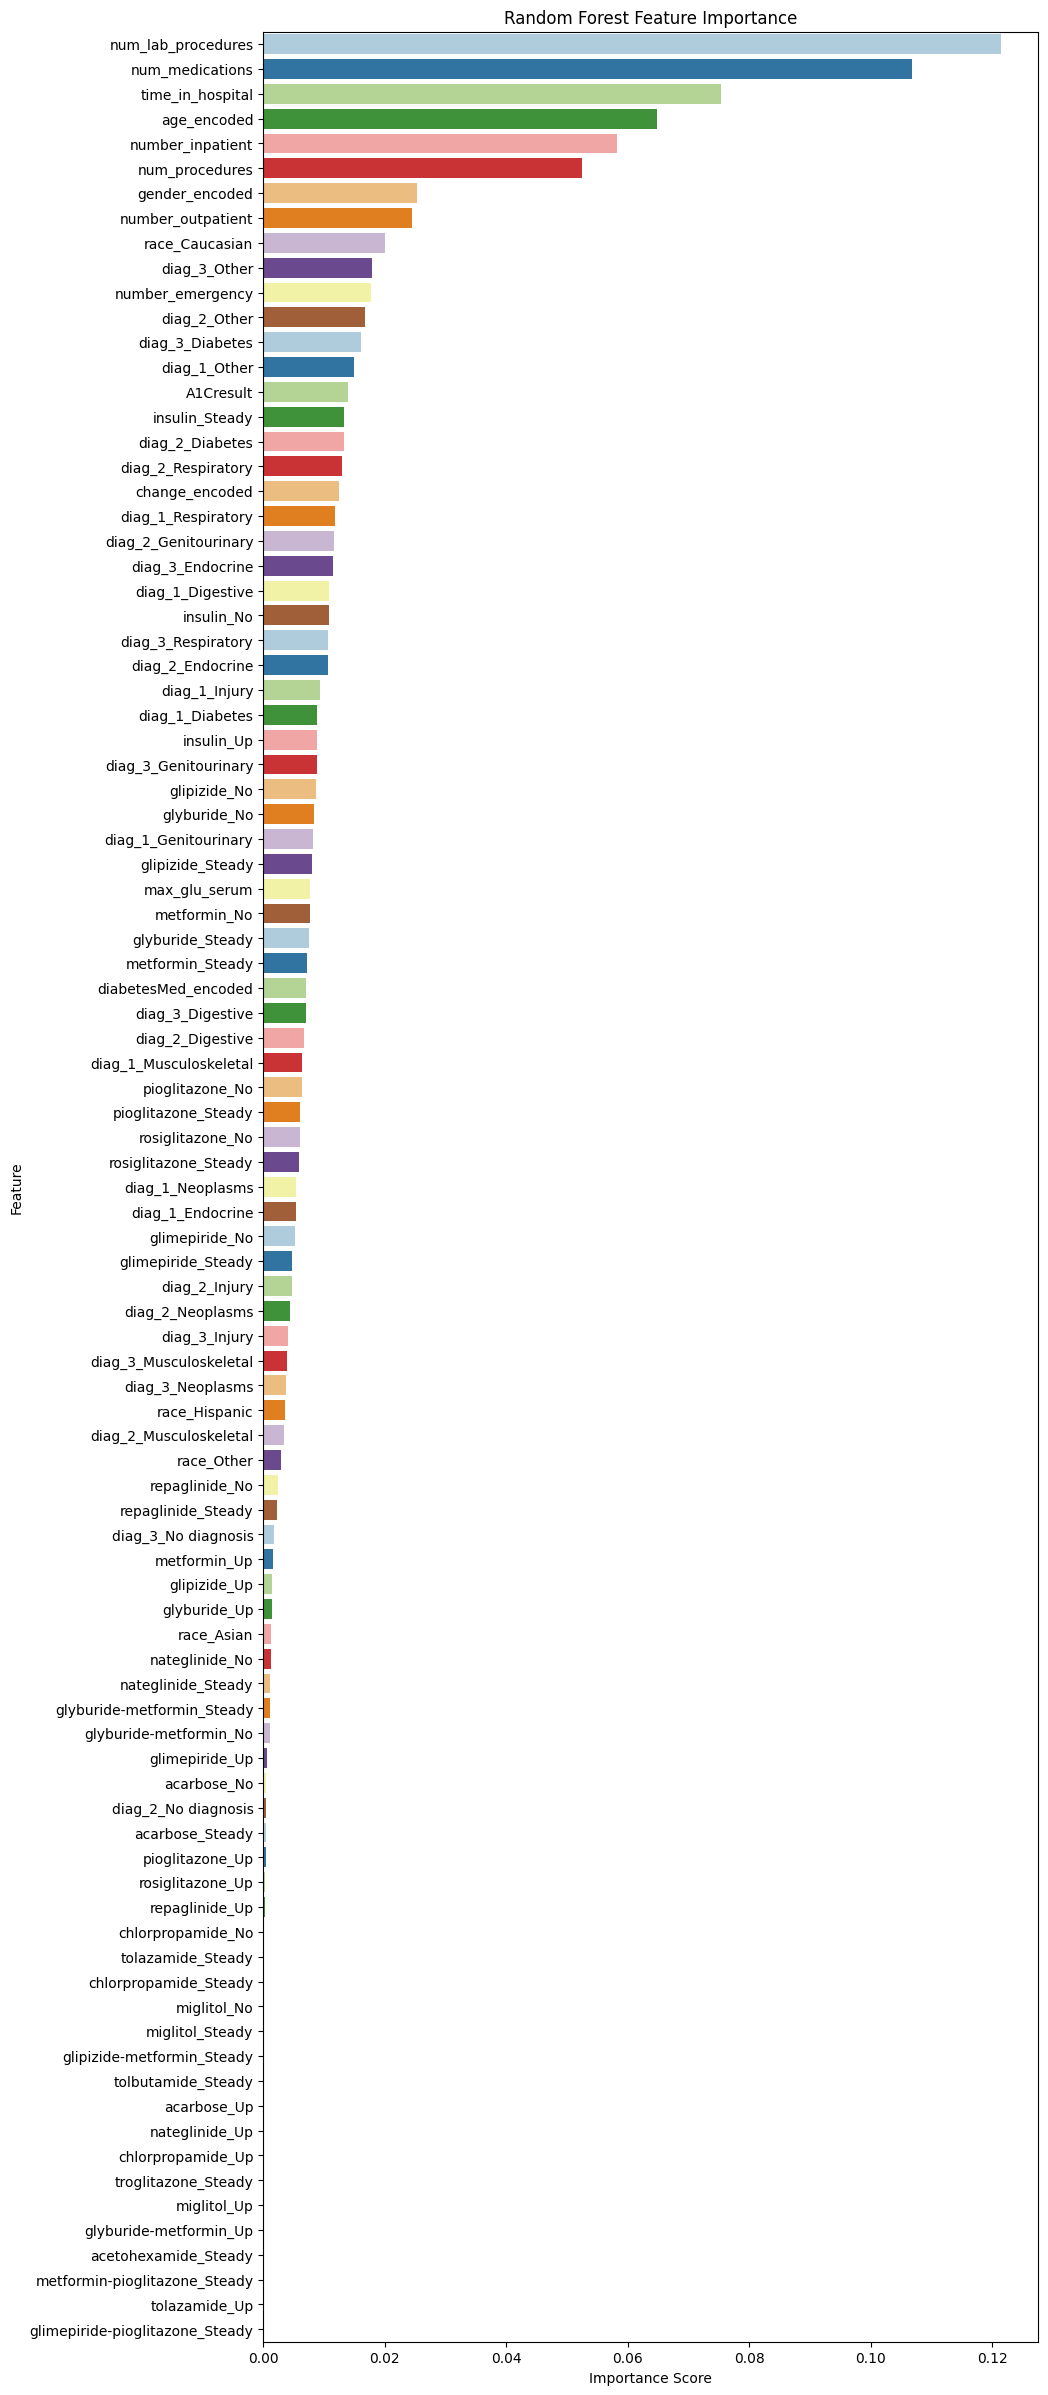

In [27]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 30))
sns.barplot(x=feature_importance.values, y=feature_importance.index, hue =feature_importance.index,  palette="Paired", legend= False)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

The Random Forest Feature importance chart measures how much each feature contirbutes to the model's prediction accuracy. It can help identify the most influential features. We can see that the choice of the model's feature importance is what led to the model having low to none reliable accuracy for this dataset.

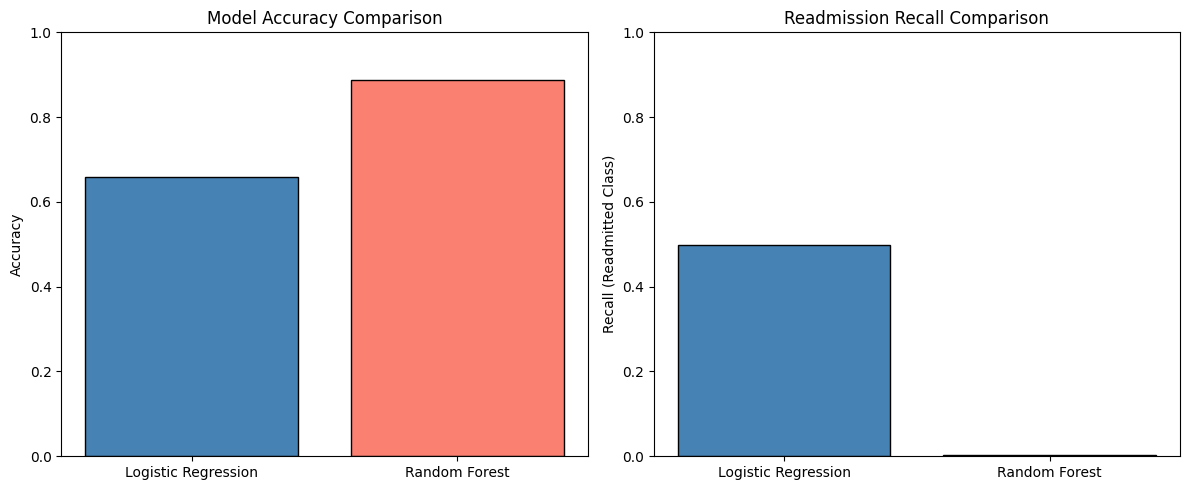

In [31]:
model_names = ["Logistic Regression", "Random Forest"]
accuracies = []
recalls = []

for name, model in [("Logistic Regression", lr_model), ("Random Forest", rf_model)]:
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))
    recalls.append(classification_report(y_test, y_pred, output_dict=True)["1"]["recall"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(model_names, accuracies, color=["steelblue", "salmon"], edgecolor="black")
axes[0].set_title("Model Accuracy Comparison")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)

axes[1].bar(model_names, recalls, color=["steelblue", "salmon"], edgecolor="black")
axes[1].set_title("Readmission Recall Comparison")
axes[1].set_ylabel("Recall (Readmitted Class)")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

The above charts show a side by side comparison of the models in terms of their accuracy and recall. The model accuracies are not an accurate representation of the viability of the models for this dataset. The Random Forest model is shown to be the most accurate model however, when tested on "Stroke recall", the Logisitic Regression model is returning the most promising results. Random forest shows completely 0 recall and so shows why accuracy can not be the only way to test how well a model works.

---

## EXPORT MODEL

In [30]:
import joblib
import os

joblib.dump(lr_model, "model/lr_model.pkl")
joblib.dump(diabetes_scaler, "model/scaler.pkl")
X_test_df = pd.DataFrame(X_test)
y_test_df = pd.DataFrame(y_test)

X_test_df.to_csv("model/X_test.csv", index=False)
y_test_df.to_csv("model/y_test.csv", index=False)

print("Everything saved successfully")

Everything saved successfully
